In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
from scipy import stats

# Deep Learning imports for GNN
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ Libraries imported successfully!
PyTorch version: 2.9.1+cpu
CUDA available: False


## 1. Helper Functions

In [2]:
def apply_rmt_filter(returns_data):
    """Apply Random Matrix Theory filtering"""
    T, N = returns_data.shape
    Q = T / N
    
    C = np.corrcoef(returns_data.T)
    eigenvalues, eigenvectors = eigh(C)
    eigenvalues = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]
    
    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    significant_mask = eigenvalues > lambda_plus
    
    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered = eigenvectors @ Lambda_filtered @ eigenvectors.T
    
    return C_filtered

def build_mst(correlation_matrix):
    """Build Minimal Spanning Tree"""
    distance_matrix = np.sqrt(2 - 2*correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix

def compute_eigenvector_centrality(distance_matrix):
    """Compute eigenvector centrality"""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    centrality = principal_eigenvector / principal_eigenvector.sum()
    
    return centrality

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """
    Graph-based diversification using Maximum Independent Set
    """
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    
    return list(nx.approximation.maximum_independent_set(G))

def calculate_var(returns, confidence=0.95):
    """Calculate Value at Risk"""
    return np.percentile(returns, (1-confidence)*100)

def calculate_rachev_ratio(returns, alpha=0.10):
    """Calculate Rachev Ratio (CVaR ratio)"""
    threshold_upper = np.percentile(returns, (1-alpha)*100)
    threshold_lower = np.percentile(returns, alpha*100)
    
    cvar_upper = returns[returns >= threshold_upper].mean()
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0

def calculate_max_drawdown(cumulative_returns):
    """Calculate Maximum Drawdown"""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()

def diebold_mariano_test(returns_a, returns_b, h=1):
    """
    Diebold-Mariano Test pada return strategi.
    Digunakan untuk menguji apakah perbedaan return signifikan secara statistik.
    """
    T = len(returns_a)
    d = returns_a - returns_b
    d_mean = np.mean(d)
    
    def autocovariance(xi, x_mean, k):
        T = len(xi)
        if T <= k: return 0
        return np.sum((xi[:T-k] - x_mean) * (xi[k:] - x_mean)) / T

    var_d = autocovariance(d, d_mean, 0)
    for i in range(1, h):
        var_d += 2 * autocovariance(d, d_mean, i)
        
    dm_stat = d_mean / np.sqrt(np.abs(var_d) / T) if var_d != 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    
    return dm_stat, p_value

## 2. Graph Neural Network Architecture

In [3]:
class CorrelationGNN(nn.Module):
    """
    Graph Neural Network for learning asset correlations
    """
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=8):
        super(CorrelationGNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.fc = nn.Linear(output_dim, 1)  # Predict correlation strength
        
    def forward(self, x, edge_index):
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        # Second GCN layer
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        return x
    
    def predict_correlation(self, node_embeddings):
        """Predict pairwise correlations from node embeddings"""
        n_nodes = node_embeddings.shape[0]
        corr_matrix = torch.zeros(n_nodes, n_nodes)
        
        for i in range(n_nodes):
            for j in range(i+1, n_nodes):
                # Cosine similarity between embeddings
                sim = F.cosine_similarity(
                    node_embeddings[i].unsqueeze(0),
                    node_embeddings[j].unsqueeze(0)
                )
                corr_matrix[i, j] = sim
                corr_matrix[j, i] = sim
        
        return corr_matrix

def create_graph_data(returns_window, corr_threshold=0.3):
    """
    Create PyTorch Geometric Data object from returns
    """
    n_assets = returns_window.shape[1]
    
    # Calculate node features
    mean_returns = returns_window.mean().values
    volatility = returns_window.std().values
    skewness = returns_window.skew().values
    kurtosis = returns_window.kurtosis().values
    
    # Stack features
    node_features = np.stack([mean_returns, volatility, skewness, kurtosis], axis=1)
    x = torch.FloatTensor(node_features)
    
    # Create edges based on correlation
    corr_mat = returns_window.corr().values
    edge_list = []
    
    for i in range(n_assets):
        for j in range(i+1, n_assets):
            if abs(corr_mat[i, j]) > corr_threshold:
                edge_list.append([i, j])
                edge_list.append([j, i])  # Undirected graph
    
    edge_index = torch.LongTensor(edge_list).t().contiguous()
    
    # Target: actual correlation matrix
    y = torch.FloatTensor(corr_mat)
    
    return Data(x=x, edge_index=edge_index, y=y)

def train_gnn(model, data, epochs=50, lr=0.01):
    """
    Train GNN to predict correlations
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Forward pass
        embeddings = model(data.x, data.edge_index)
        pred_corr = model.predict_correlation(embeddings)
        
        # Loss: MSE between predicted and actual correlation
        loss = criterion(pred_corr, data.y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # if (epoch + 1) % 10 == 0:
        #    print(f"  Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
    
    return model

## 3. Strategy Implementations

In [4]:
class PortfolioStrategy:
    """Base class for portfolio strategies"""
    def __init__(self, name):
        self.name = name
        self.weights_history = []
        self.returns_history = []
    
    def get_weights(self, returns_data):
        raise NotImplementedError
    
    def calculate_portfolio_return(self, weights, future_returns):
        return np.dot(weights, future_returns)

class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        cov_matrix = returns_data.cov().values
        
        def objective(w):
            return w @ cov_matrix @ w
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class GlassoMarkowitz(PortfolioStrategy):
    def __init__(self, name="Glasso Markowitz", alpha=0.01):
        super().__init__(name)
        self.alpha = alpha
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        
        try:
            glasso = GraphicalLassoCV(alphas=[self.alpha], cv=3)
            glasso.fit(returns_data.values)
            cov_matrix = glasso.covariance_
        except:
            cov_matrix = returns_data.cov().values
        
        def objective(w):
            return w @ cov_matrix @ w
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name="Network Markowitz", gamma=0):
        super().__init__(name)
        self.gamma = gamma
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        std_devs = returns_data.std().values
        
        C_filtered = apply_rmt_filter(returns_data)
        dist_matrix = build_mst(C_filtered)
        centrality = compute_eigenvector_centrality(dist_matrix)
        
        cov_filtered = np.outer(std_devs, std_devs) * C_filtered
        
        def objective(w):
            portfolio_variance = w @ cov_filtered @ w
            centrality_penalty = self.gamma * np.sum(centrality * w)
            return portfolio_variance + centrality_penalty
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class GraphDiversification(PortfolioStrategy):
    def __init__(self, name="Graph Diversification", corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        all_assets = returns_data.columns.tolist()
        
        selected_assets = get_assets_graph_diversify(returns_data, self.corr_threshold)
        
        weights = np.zeros(n_assets)
        n_selected = len(selected_assets)
        
        if n_selected > 0:
            for asset in selected_assets:
                idx = all_assets.index(asset)
                weights[idx] = 1.0 / n_selected
        else:
            weights = np.ones(n_assets) / n_assets
        
        return weights

class GNNGraphDiversification(PortfolioStrategy):
    def __init__(self, name="GNN Graph Diversification", base_threshold=0.4, train_epochs=30):
        super().__init__(name)
        self.base_threshold = base_threshold
        self.train_epochs = train_epochs
        self.gnn_model = CorrelationGNN(input_dim=4, hidden_dim=16, output_dim=8)
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        all_assets = returns_data.columns.tolist()
        
        graph_data = create_graph_data(returns_data, corr_threshold=0.3)
        self.gnn_model = train_gnn(self.gnn_model, graph_data, epochs=self.train_epochs, lr=0.01)
        
        self.gnn_model.eval()
        with torch.no_grad():
            embeddings = self.gnn_model(graph_data.x, graph_data.edge_index)
            pred_corr = self.gnn_model.predict_correlation(embeddings)
        
        pred_corr_np = pred_corr.numpy()
        upper_triangle = pred_corr_np[np.triu_indices(n_assets, k=1)]
        dynamic_threshold = np.mean(np.abs(upper_triangle)) + 0.5 * np.std(np.abs(upper_triangle))
        dynamic_threshold = np.clip(dynamic_threshold, 0.3, 0.7)
        
        G = nx.Graph()
        mean_returns = returns_data.mean()
        assets_sorted = list(mean_returns.sort_values(ascending=False).index)
        G.add_nodes_from(assets_sorted)
        
        for i, a1 in enumerate(assets_sorted):
            for a2 in assets_sorted[i+1:]:
                idx1 = all_assets.index(a1)
                idx2 = all_assets.index(a2)
                if abs(pred_corr_np[idx1, idx2]) > dynamic_threshold:
                    G.add_edge(a1, a2)
        
        selected_assets = list(nx.approximation.maximum_independent_set(G))
        weights = np.zeros(n_assets)
        n_selected = len(selected_assets)
        
        if n_selected > 0:
            for asset in selected_assets:
                idx = all_assets.index(asset)
                weights[idx] = 1.0 / n_selected
        else:
            weights = np.ones(n_assets) / n_assets
        
        return weights

## 4. Backtesting Framework

In [5]:
def backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7, transaction_cost=0.001):
    portfolio_returns = []
    weights_history = []
    dates = []
    
    for i in range(window_size, len(df_returns), rebalance_freq):
        train_data = df_returns.iloc[i-window_size:i]
        weights = strategy.get_weights(train_data)
        weights_history.append(weights)
        
        test_end = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]
        
        for j in range(len(test_data)):
            daily_return = np.dot(weights, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_return -= transaction_cost
            portfolio_returns.append(daily_return)
            dates.append(test_data.index[j])
    
    results_df = pd.DataFrame({'date': dates, 'return': portfolio_returns})
    results_df['cumulative_return'] = (1 + results_df['return']).cumprod()
    
    return {
        'strategy': strategy.name,
        'returns': np.array(portfolio_returns),
        'cumulative_returns': results_df['cumulative_return'].values,
        'dates': dates,
        'weights_history': weights_history,
        'results_df': results_df
    }

def calculate_metrics(result):
    returns = result['returns']
    cum_returns = result['cumulative_returns']
    
    annual_return = np.mean(returns) * 252
    annual_vol = np.std(returns) * np.sqrt(252)
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0
    
    var_95 = calculate_var(returns, 0.95)
    rachev = calculate_rachev_ratio(returns, 0.10)
    max_dd = calculate_max_drawdown(cum_returns)
    total_return = cum_returns[-1] - 1
    
    return {
        'Strategy': result['strategy'],
        'Total Return (%)': total_return * 100,
        'Annual Return (%)': annual_return * 100,
        'Annual Volatility (%)': annual_vol * 100,
        'Sharpe Ratio': sharpe,
        'VaR 95% (%)': var_95 * 100,
        'Rachev Ratio': rachev,
        'Max Drawdown (%)': max_dd * 100
    }

## 5. Main Execution

Running backtests...

Testing: Equally Weighted...
  ✓ Completed
Testing: Classical Markowitz...
  ✓ Completed
Testing: Glasso Markowitz...
  ✓ Completed
Testing: Network Markowitz (γ=0)...
  ✓ Completed
Testing: Network Markowitz (γ=1.0)...
  ✓ Completed
Testing: Graph Diversification (θ=0.4)...
  ✓ Completed
Testing: Graph Diversification (θ=0.5)...
  ✓ Completed
Testing: GNN Graph Diversification (30 epochs)...
  ✓ Completed
Testing: GNN Graph Diversification (50 epochs)...


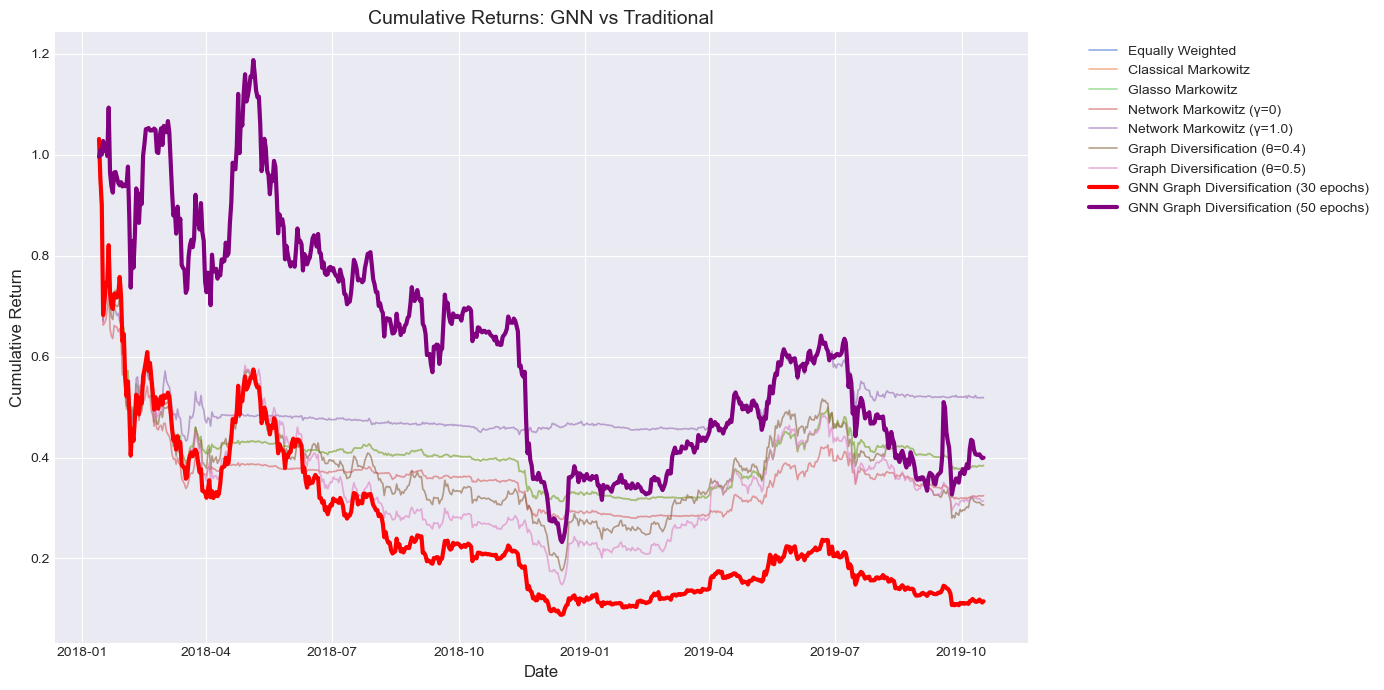

In [6]:
if __name__ == "__main__":
    # Load data
    excel_file = 'crypto_data_real.xlsx'
    df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
    
    strategies = [
        EquallyWeighted("Equally Weighted"),
        ClassicalMarkowitz("Classical Markowitz"),
        GlassoMarkowitz("Glasso Markowitz", alpha=0.01),
        NetworkMarkowitz("Network Markowitz (\u03b3=0)", gamma=0),
        NetworkMarkowitz("Network Markowitz (\u03b3=1.0)", gamma=1.0),
        GraphDiversification("Graph Diversification (\u03b8=0.4)", corr_threshold=0.4),
        GraphDiversification("Graph Diversification (\u03b8=0.5)", corr_threshold=0.5),
        GNNGraphDiversification("GNN Graph Diversification (30 epochs)", train_epochs=30),
        GNNGraphDiversification("GNN Graph Diversification (50 epochs)", train_epochs=50),
    ]

    print("Running backtests...\n")
    results = {}
    for strategy in strategies:
        print(f"Testing: {strategy.name}...")
        result = backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7)
        results[strategy.name] = result
        print(f"  \u2713 Completed")

    # Performance Metrics
    metrics_list = [calculate_metrics(result) for result in results.values()]
    metrics_df = pd.DataFrame(metrics_list)
    
    print("\n\ud83d\udcca PERFORMANCE METRICS")
    print("="*120)
    print(metrics_df.to_string(index=False))
    print("="*120)

    # --- NEW: Statistical Significance Test (Diebold-Mariano) ---
    print("\n\ud83d\udd0d STATISTICAL VALIDATION (Diebold-Mariano Test)")
    print("-" * 60)
    benchmark_name = "Classical Markowitz"
    gnn_name = "GNN Graph Diversification (50 epochs)"

    if benchmark_name in results and gnn_name in results:
        returns_bench = results[benchmark_name]['returns']
        returns_gnn = results[gnn_name]['returns']
        
        dm_stat, p_val = diebold_mariano_test(returns_gnn, returns_bench)
        
        print(f"Comparison: {gnn_name} vs {benchmark_name}")
        print(f"DM Statistic: {dm_stat:.4f}")
        print(f"P-Value: {p_val:.4f}")
        
        if p_val < 0.05:
            print("Result: \u2705 Significant Difference (alpha=0.05)")
            if dm_stat > 0:
                print(f"Conclusion: {gnn_name} significantly outperforms {benchmark_name}.")
            else:
                print(f"Conclusion: {benchmark_name} significantly outperforms {gnn_name}.")
        else:
            print("Result: \u274c No Significant Difference (alpha=0.05)")
            print("Conclusion: Performa differences could be due to randomness.")
    print("-" * 60)

    # Visualization
    plt.figure(figsize=(14, 7))
    
    # Custom colors and line widths to make GNN stand out
    gnn_colors = ['red', 'purple']
    other_colors = sns.color_palette("muted", len(strategies) - 2)
    
    gnn_idx = 0
    other_idx = 0
    
    for name, res in results.items():
        if "GNN" in name:
            plt.plot(res['dates'], res['cumulative_returns'], label=name, color=gnn_colors[gnn_idx], linewidth=3.0)
            gnn_idx += 1
        else:
            plt.plot(res['dates'], res['cumulative_returns'], label=name, color=other_colors[other_idx], linewidth=1.2, alpha=0.6)
            other_idx += 1

    plt.title("Cumulative Returns: GNN vs Traditional", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Return", fontsize=12)
    
    # Menempatkan legend di luar grafik agar tidak menutupi garis
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    
    plt.savefig('cumulative_returns_comparison.png', dpi=300)
    plt.show()